##**Loading Dataset**

In [2]:
import pandas as pd
application=pd.read_csv('/content/application_record.csv')
credit=pd.read_csv('/content/credit_record.csv')
credit['bad_customer'] = credit['STATUS'].isin(['1','2','3','4','5'])

target = (
    credit.groupby('ID')['bad_customer']
          .max()
          .reset_index()
)

target['APPROVED'] = 1 - target['bad_customer']

In [3]:
df = application.merge(target[['ID','APPROVED']], on='ID')
df

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,APPROVED
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,1
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,1
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36452,5149828,M,Y,Y,0,315000.0,Working,Secondary / secondary special,Married,House / apartment,-17348,-2420,1,0,0,0,Managers,2.0,0
36453,5149834,F,N,Y,0,157500.0,Commercial associate,Higher education,Married,House / apartment,-12387,-1325,1,0,1,1,Medicine staff,2.0,0
36454,5149838,F,N,Y,0,157500.0,Pensioner,Higher education,Married,House / apartment,-12387,-1325,1,0,1,1,Medicine staff,2.0,0
36455,5150049,F,N,Y,0,283500.0,Working,Secondary / secondary special,Married,House / apartment,-17958,-655,1,0,0,0,Sales staff,2.0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   36457 non-null  int64  
 1   CODE_GENDER          36457 non-null  object 
 2   FLAG_OWN_CAR         36457 non-null  object 
 3   FLAG_OWN_REALTY      36457 non-null  object 
 4   CNT_CHILDREN         36457 non-null  int64  
 5   AMT_INCOME_TOTAL     36457 non-null  float64
 6   NAME_INCOME_TYPE     36457 non-null  object 
 7   NAME_EDUCATION_TYPE  36457 non-null  object 
 8   NAME_FAMILY_STATUS   36457 non-null  object 
 9   NAME_HOUSING_TYPE    36457 non-null  object 
 10  DAYS_BIRTH           36457 non-null  int64  
 11  DAYS_EMPLOYED        36457 non-null  int64  
 12  FLAG_MOBIL           36457 non-null  int64  
 13  FLAG_WORK_PHONE      36457 non-null  int64  
 14  FLAG_PHONE           36457 non-null  int64  
 15  FLAG_EMAIL           36457 non-null 

In [ ]:
df.isnull().sum()

,0
ID,0
CODE_GENDER,0
FLAG_OWN_CAR,0
FLAG_OWN_REALTY,0
CNT_CHILDREN,0
AMT_INCOME_TOTAL,0
NAME_INCOME_TYPE,0
NAME_EDUCATION_TYPE,0
NAME_FAMILY_STATUS,0
NAME_HOUSING_TYPE,0


In [ ]:
df['APPROVED'].value_counts()

,count
APPROVED,
1,32166
0,4291


In [4]:
df.drop_duplicates(inplace=True)
df['OCCUPATION_TYPE'].fillna('Unknown', inplace=True)

/tmp/ipykernel_828/3468972957.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['OCCUPATION_TYPE'].fillna('Unknown', inplace=True)


In [4]:
df

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,APPROVED
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Unknown,2.0,0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Unknown,2.0,0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,1
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,1
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36452,5149828,M,Y,Y,0,315000.0,Working,Secondary / secondary special,Married,House / apartment,-17348,-2420,1,0,0,0,Managers,2.0,0
36453,5149834,F,N,Y,0,157500.0,Commercial associate,Higher education,Married,House / apartment,-12387,-1325,1,0,1,1,Medicine staff,2.0,0
36454,5149838,F,N,Y,0,157500.0,Pensioner,Higher education,Married,House / apartment,-12387,-1325,1,0,1,1,Medicine staff,2.0,0
36455,5150049,F,N,Y,0,283500.0,Working,Secondary / secondary special,Married,House / apartment,-17958,-655,1,0,0,0,Sales staff,2.0,0


##**Feature Engineering**

In [5]:
df['AGE'] = round(abs(df['DAYS_BIRTH'])/365,0)
df['EMPLOYED_YEARS'] = round(abs(df['DAYS_EMPLOYED'])/365,0)
df

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,...,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,APPROVED,AGE,EMPLOYED_YEARS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,-4542,1,1,0,0,Unknown,2.0,0,33.0,12.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,-4542,1,1,0,0,Unknown,2.0,0,33.0,12.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,...,-1134,1,0,0,0,Security staff,2.0,1,59.0,3.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,-3051,1,0,1,1,Sales staff,1.0,1,52.0,8.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,-3051,1,0,1,1,Sales staff,1.0,1,52.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36452,5149828,M,Y,Y,0,315000.0,Working,Secondary / secondary special,Married,House / apartment,...,-2420,1,0,0,0,Managers,2.0,0,48.0,7.0
36453,5149834,F,N,Y,0,157500.0,Commercial associate,Higher education,Married,House / apartment,...,-1325,1,0,1,1,Medicine staff,2.0,0,34.0,4.0
36454,5149838,F,N,Y,0,157500.0,Pensioner,Higher education,Married,House / apartment,...,-1325,1,0,1,1,Medicine staff,2.0,0,34.0,4.0
36455,5150049,F,N,Y,0,283500.0,Working,Secondary / secondary special,Married,House / apartment,...,-655,1,0,0,0,Sales staff,2.0,0,49.0,2.0


##**Statistical Analysis**

In [6]:
##Statistical Tests
from scipy.stats import chi2_contingency

categorical_cols = [
    'CODE_GENDER',
    'FLAG_OWN_CAR',
    'FLAG_OWN_REALTY',
    'NAME_INCOME_TYPE',
    'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS',
    'NAME_HOUSING_TYPE',
    'OCCUPATION_TYPE'
]

for col in categorical_cols:

    contingency_table = pd.crosstab(
        df[col],
        df['APPROVED']
    )

    chi2, p, dof, expected = chi2_contingency(contingency_table)

    print("\n", col)
    print("Chi-square statistic:", chi2)
    print("p-value:", p)

    ##There are significant evidence of a strong association between credit card approval status and
    ##gender,whether a person having car, realty, person's income, education, family status, housing
    ##type, occupation.


 CODE_GENDER
Chi-square statistic: 16.333243819597886
p-value: 5.312379078891809e-05

 FLAG_OWN_CAR
Chi-square statistic: 4.0137432693319015
p-value: 0.0451308461717382

 FLAG_OWN_REALTY
Chi-square statistic: 28.378057359995655
p-value: 9.978998339119105e-08

 NAME_INCOME_TYPE
Chi-square statistic: 21.75559368661593
p-value: 0.00022416548703410756

 NAME_EDUCATION_TYPE
Chi-square statistic: 15.732403535949505
p-value: 0.0034000835490459744

 NAME_FAMILY_STATUS
Chi-square statistic: 12.187763788074333
p-value: 0.016008280065041444

 NAME_HOUSING_TYPE
Chi-square statistic: 11.332192148491808
p-value: 0.0451772062193244

 OCCUPATION_TYPE
Chi-square statistic: 63.251711957758836
p-value: 6.038711948008026e-07


(array([2.0850e+03, 7.9120e+03, 1.2463e+04, 6.2740e+03, 3.2300e+03,
        1.8760e+03, 1.2500e+03, 4.1200e+02, 4.3700e+02, 1.4300e+02,
        6.9000e+01, 6.2000e+01, 1.2500e+02, 2.6000e+01, 1.4000e+01,
        1.5000e+01, 3.9000e+01, 4.0000e+00, 4.0000e+00, 0.0000e+00,
        0.0000e+00, 3.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        6.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 8.0000e+00]),
 array([  27000.,   78600.,  130200.,  181800.,  233400.,  285000.,
         336600.,  388200.,  439800.,  491400.,  543000.,  594600.,
         646200.,  697800.,  749400.,  801000.,  852600.,  904200.,
         955800., 1007400., 1059000., 1110600., 1162200., 1213800.,
        1265400., 1317000., 1368600., 1420200., 1471800., 1523400.,
        1575000.]),
 <BarContainer object of 30 artists>)

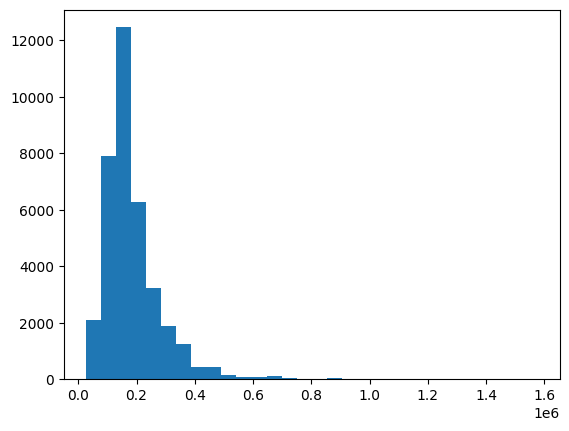

In [8]:
##Checking the distribution of income
from matplotlib import pyplot as plt
plt.hist(df['AMT_INCOME_TOTAL'],bins=30)

In [10]:
##Is the mean income different between approved and rejected applicants?
from scipy.stats import mannwhitneyu
group_0 = df[df['APPROVED'] == 0]['AMT_INCOME_TOTAL']
group_1 = df[df['APPROVED'] == 1]['AMT_INCOME_TOTAL']

statistic, p_value = mannwhitneyu(
    group_0,
    group_1,
    alternative='two-sided'
)

print("\n", 'AMT_INCOME_TOTAL')
print("U statistic:", statistic)
print("p-value:", p_value)
##In the light of the given data it seems that there is a significant difference in income
##distribution between approved and rejected applicants.


 AMT_INCOME_TOTAL
U statistic: 71036438.0
p-value: 0.0017306638258593023


In [11]:
df = df.drop(['DAYS_EMPLOYED', 'FLAG_MOBIL','FLAG_WORK_PHONE','FLAG_PHONE','FLAG_EMAIL','DAYS_BIRTH'], axis=1)
df

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,OCCUPATION_TYPE,CNT_FAM_MEMBERS,APPROVED,AGE,EMPLOYED_YEARS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,Unknown,2.0,0,33.0,12.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,Unknown,2.0,0,33.0,12.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,Security staff,2.0,1,59.0,3.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,Sales staff,1.0,1,52.0,8.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,Sales staff,1.0,1,52.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36452,5149828,M,Y,Y,0,315000.0,Working,Secondary / secondary special,Married,House / apartment,Managers,2.0,0,48.0,7.0
36453,5149834,F,N,Y,0,157500.0,Commercial associate,Higher education,Married,House / apartment,Medicine staff,2.0,0,34.0,4.0
36454,5149838,F,N,Y,0,157500.0,Pensioner,Higher education,Married,House / apartment,Medicine staff,2.0,0,34.0,4.0
36455,5150049,F,N,Y,0,283500.0,Working,Secondary / secondary special,Married,House / apartment,Sales staff,2.0,0,49.0,2.0


##**EDA**


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

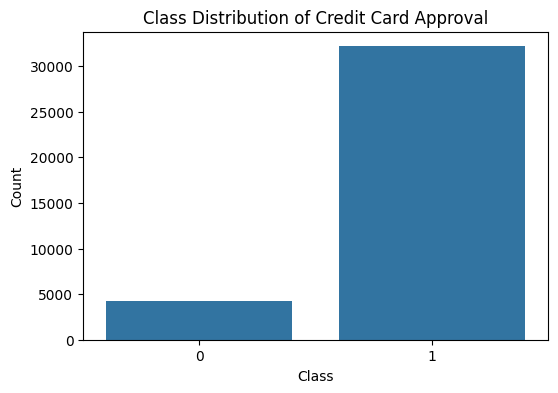

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='APPROVED', data=df)
plt.title("Class Distribution of Credit Card Approval")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

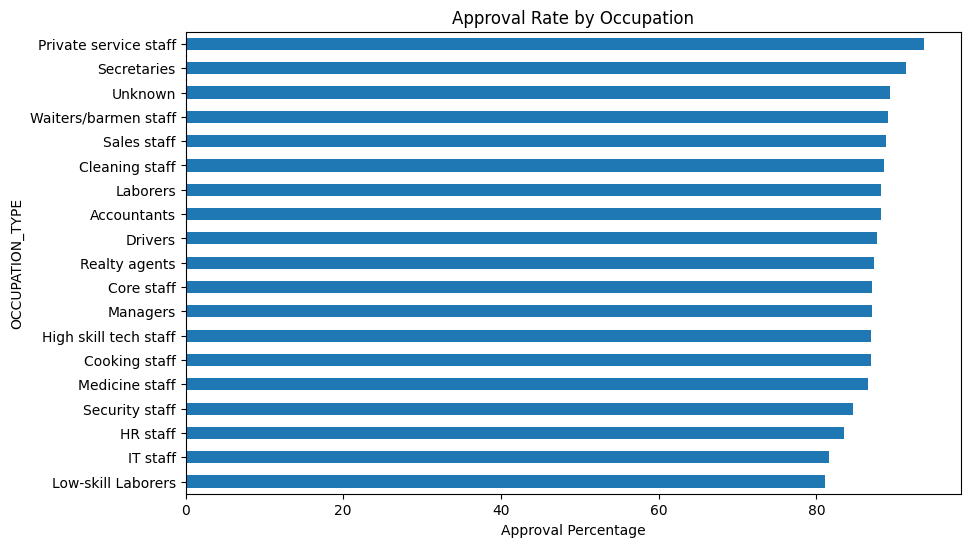

In [13]:
approval_occ = pd.crosstab(
    df['OCCUPATION_TYPE'],
    df['APPROVED'],
    normalize='index'
)*100

approval_occ[1].sort_values().plot(
    kind='barh',
    figsize=(10,6)
)

plt.xlabel('Approval Percentage')
plt.title('Approval Rate by Occupation')
plt.show()

##From the graph we can conclude that the approval rate varies across different job categories.
##Private service staff and secretaries have very high approval rate whereas low-skill laborers
##have lowest credit card approval rate.

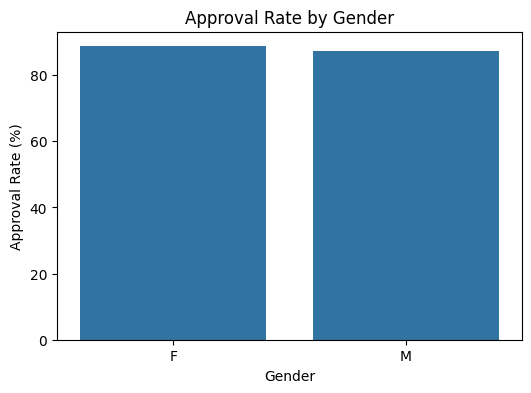

In [14]:
approval_rate_gender = (
    df.groupby('CODE_GENDER')['APPROVED']
      .mean()
      .reset_index()
)

approval_rate_gender['APPROVED'] *= 100

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.barplot(
    x='CODE_GENDER',
    y='APPROVED',
    data=approval_rate_gender
)

plt.ylabel('Approval Rate (%)')
plt.xlabel('Gender')
plt.title('Approval Rate by Gender')
plt.show()
##the credit card approval rate for both the genders are almost same though having slightly higher
##approval rate for female applicants.

In [15]:
df = df.drop('Income_Group', axis=1)
df

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,OCCUPATION_TYPE,CNT_FAM_MEMBERS,APPROVED,AGE,EMPLOYED_YEARS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,Unknown,2.0,0,33.0,12.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,Unknown,2.0,0,33.0,12.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,Security staff,2.0,1,59.0,3.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,Sales staff,1.0,1,52.0,8.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,Sales staff,1.0,1,52.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36452,5149828,M,Y,Y,0,315000.0,Working,Secondary / secondary special,Married,House / apartment,Managers,2.0,0,48.0,7.0
36453,5149834,F,N,Y,0,157500.0,Commercial associate,Higher education,Married,House / apartment,Medicine staff,2.0,0,34.0,4.0
36454,5149838,F,N,Y,0,157500.0,Pensioner,Higher education,Married,House / apartment,Medicine staff,2.0,0,34.0,4.0
36455,5150049,F,N,Y,0,283500.0,Working,Secondary / secondary special,Married,House / apartment,Sales staff,2.0,0,49.0,2.0


##**Data Preprocessing**
##### Selecting categorical variable and One-Hot Encoding

In [16]:
import pandas as pd

# Identify categorical columns
categorical_columns = df.select_dtypes(include=['object']).columns

# Apply One-Hot Encoding
df = pd.get_dummies(df,
                    columns=categorical_columns,
                    drop_first=True)

# View first few rows
print(df.head())
print(categorical_columns)

        ID  CNT_CHILDREN  AMT_INCOME_TOTAL  CNT_FAM_MEMBERS  APPROVED   AGE  \
0  5008804             0          427500.0              2.0         0  33.0   
1  5008805             0          427500.0              2.0         0  33.0   
2  5008806             0          112500.0              2.0         1  59.0   
3  5008808             0          270000.0              1.0         1  52.0   
4  5008809             0          270000.0              1.0         1  52.0   

   EMPLOYED_YEARS  CODE_GENDER_M  FLAG_OWN_CAR_Y  FLAG_OWN_REALTY_Y  ...  \
0            12.0           True            True               True  ...   
1            12.0           True            True               True  ...   
2             3.0           True            True               True  ...   
3             8.0          False           False               True  ...   
4             8.0          False           False               True  ...   

   OCCUPATION_TYPE_Low-skill Laborers  OCCUPATION_TYPE_Managers  \
0

In [18]:
X = df.drop(['ID','APPROVED'], axis=1)
y = df['APPROVED']
print(X,y)

       CNT_CHILDREN  AMT_INCOME_TOTAL  CNT_FAM_MEMBERS   AGE  EMPLOYED_YEARS  \
0                 0          427500.0              2.0  33.0            12.0   
1                 0          427500.0              2.0  33.0            12.0   
2                 0          112500.0              2.0  59.0             3.0   
3                 0          270000.0              1.0  52.0             8.0   
4                 0          270000.0              1.0  52.0             8.0   
...             ...               ...              ...   ...             ...   
36452             0          315000.0              2.0  48.0             7.0   
36453             0          157500.0              2.0  34.0             4.0   
36454             0          157500.0              2.0  34.0             4.0   
36455             0          283500.0              2.0  49.0             2.0   
36456             0          112500.0              1.0  25.0             3.0   

       CODE_GENDER_M  FLAG_OWN_CAR_Y  F

##**Train-Test Split**

In [19]:
##Train test-split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

##**Applying SMOTE**

In [20]:
##Applying smote
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print(y_train.value_counts())
print(y_train_smote.value_counts())

APPROVED
1    25732
0     3433
Name: count, dtype: int64
APPROVED
1    25732
0    25732
Name: count, dtype: int64


##**Standardization**


In [21]:
##Standardization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report,ConfusionMatrixDisplay, \
                            precision_score, recall_score, f1_score, roc_auc_score,roc_curve,confusion_matrix

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

##**Model Fitting**
####Logistic Regression


In [24]:
##Logistic regression
log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train_scaled, y_train_smote)

y_pred_log = log_model.predict(X_test_scaled)

In [25]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [43]:
##Metrics
print("Logistic Regression")

print("Accuracy:", accuracy_score(y_test, y_pred_log))

print(recall_score(y_test, y_pred_log))

print("F1-score:",f1_score(y_test, y_pred_log,average='weighted'))
print(roc_auc_score(y_test, y_pred_log))
print(precision_score(y_test, y_pred_log))
print(confusion_matrix(y_test, y_pred_log))

print(classification_report(y_test, y_pred_log))

Logistic Regression
Accuracy: 0.8811025781678552
0.9968915138327634
F1-score: 0.8293898260425329
0.5048560133266381
0.8833494009089657
[[  11  847]
 [  20 6414]]
              precision    recall  f1-score   support

           0       0.35      0.01      0.02       858
           1       0.88      1.00      0.94      6434

    accuracy                           0.88      7292
   macro avg       0.62      0.50      0.48      7292
weighted avg       0.82      0.88      0.83      7292



##### Decision Tree

In [28]:
##Decision Tree
tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=8
)

tree_model.fit(X_train_smote, y_train_smote)

y_pred_tree = tree_model.predict(X_test)

In [44]:
print("Decision Tree")

print("Accuracy:", accuracy_score(y_test, y_pred_tree))

print(confusion_matrix(y_test, y_pred_tree))

print(classification_report(y_test, y_pred_tree))
print("F1-score:",f1_score(y_test, y_pred_tree,average='weighted'))

Decision Tree
Accuracy: 0.6876028524410313
[[ 320  538]
 [1740 4694]]
              precision    recall  f1-score   support

           0       0.16      0.37      0.22       858
           1       0.90      0.73      0.80      6434

    accuracy                           0.69      7292
   macro avg       0.53      0.55      0.51      7292
weighted avg       0.81      0.69      0.74      7292

F1-score: 0.7358512669402979


##### Random Forest

In [30]:
##Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train_smote, y_train_smote)

y_pred_rf = rf_model.predict(X_test)

In [45]:
print("Random Forest")

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print(confusion_matrix(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))
print("F1-score:",f1_score(y_test, y_pred_rf,average='weighted'))

Random Forest
Accuracy: 0.8684860120680198
[[ 349  509]
 [ 450 5984]]
              precision    recall  f1-score   support

           0       0.44      0.41      0.42       858
           1       0.92      0.93      0.93      6434

    accuracy                           0.87      7292
   macro avg       0.68      0.67      0.67      7292
weighted avg       0.86      0.87      0.87      7292

F1-score: 0.866444755373865


##### XGBoost

In [32]:
##XGBoost
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train_smote, y_train_smote)

y_pred_xgb = xgb_model.predict(X_test)

In [46]:
print("XGBoost")

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))

print(confusion_matrix(y_test, y_pred_xgb))

print(classification_report(y_test, y_pred_xgb))
print("F1-score:",f1_score(y_test, y_pred_xgb,average='weighted'))

XGBoost
Accuracy: 0.8756171146461876
[[ 144  714]
 [ 193 6241]]
              precision    recall  f1-score   support

           0       0.43      0.17      0.24       858
           1       0.90      0.97      0.93      6434

    accuracy                           0.88      7292
   macro avg       0.66      0.57      0.59      7292
weighted avg       0.84      0.88      0.85      7292

F1-score: 0.8509227135098558


##**Model Evaluation**

In [49]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'XGBoost'
    ],
    'F1-score': [
        f1_score(y_test, y_pred_log,average='weighted'),
        f1_score(y_test, y_pred_tree,average='weighted'),
        f1_score(y_test, y_pred_rf,average='weighted'),
        f1_score(y_test, y_pred_xgb,average='weighted')
    ]
})

print(results)

                 Model  F1-score
0  Logistic Regression  0.829390
1        Decision Tree  0.735851
2        Random Forest  0.866445
3              XGBoost  0.850923


In [35]:
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import classification_report, roc_auc_score

models = {
    "Logistic Regression": log_model,
    "Decision Tree": tree_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

for name, model in models.items():
    # Use scaled data for Logistic Regression, unscaled for others
    if name == "Logistic Regression":
        X_test_for_prediction = X_test_scaled
    else:
        X_test_for_prediction = X_test

    y_pred = model.predict(X_test_for_prediction)

    # probability for ROC-AUC
    y_prob = model.predict_proba(X_test_for_prediction)[:,1]

    print("="*60)
    print(name)

    print("Accuracy :", accuracy_score(y_test, y_pred))

    print("\nConfusion Matrix")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

    print("ROC-AUC :", roc_auc_score(y_test, y_prob))

Logistic Regression
Accuracy : 0.8811025781678552

Confusion Matrix
[[  11  847]
 [  20 6414]]

Classification Report
              precision    recall  f1-score   support

           0       0.35      0.01      0.02       858
           1       0.88      1.00      0.94      6434

    accuracy                           0.88      7292
   macro avg       0.62      0.50      0.48      7292
weighted avg       0.82      0.88      0.83      7292

ROC-AUC : 0.5300573946828221
Decision Tree
Accuracy : 0.6876028524410313

Confusion Matrix
[[ 320  538]
 [1740 4694]]

Classification Report
              precision    recall  f1-score   support

           0       0.16      0.37      0.22       858
           1       0.90      0.73      0.80      6434

    accuracy                           0.69      7292
   macro avg       0.53      0.55      0.51      7292
weighted avg       0.81      0.69      0.74      7292

ROC-AUC : 0.5723248360798874
Random Forest
Accuracy : 0.8684860120680198

Confusion Mat

##**Hyperparameter Tuning**

In [36]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, None]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train_smote, y_train_smote)



Fitting 5 folds for each of 4 candidates, totalling 20 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, None], 'n_estimators': [100, 200]},
             scoring='roc_auc', verbose=2)

In [37]:
grid_search.best_params_

{'max_depth': None, 'n_estimators': 200}

In [38]:
best_rf = grid_search.best_estimator_

best_rf.fit(X_train_smote, y_train_smote)

y_pred_best = best_rf.predict(X_test)
y_prob_best = best_rf.predict_proba(X_test)[:,1]

In [39]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score

print("Tuned Random Forest")

print("Accuracy:",
      accuracy_score(y_test, y_pred_best))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_best))

print("\nClassification Report")
print(classification_report(y_test, y_pred_best))

print("\nROC-AUC:",
      roc_auc_score(y_test, y_prob_best))

Tuned Random Forest
Accuracy: 0.8684860120680198

Confusion Matrix
[[ 349  509]
 [ 450 5984]]

Classification Report
              precision    recall  f1-score   support

           0       0.44      0.41      0.42       858
           1       0.92      0.93      0.93      6434

    accuracy                           0.87      7292
   macro avg       0.68      0.67      0.67      7292
weighted avg       0.86      0.87      0.87      7292


ROC-AUC: 0.7868727868339307


##**Cross-Validation**

In [40]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
import numpy as np

pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

cv_scores = cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

print(cv_scores)
print("Mean ROC-AUC:", np.mean(cv_scores))
print("Std:", np.std(cv_scores))


[0.78711707 0.77441372 0.7684782  0.75748055 0.7675193 ]
Mean ROC-AUC: 0.7710017660344943
Std: 0.00972279494663446
